
# Project Milestone One: Forming Your Team, Understanding the Problem, and Exploring the Data

#### **Due:** Midnight on October 26th (with 2-hour grace period) — **worth 25 points**

> **Note:** Because we must begin manual grading immediately, there will be *no* late period for this milestone.

This milestone is the first phase of your project. You’ll begin working in teams, select your dataset, perform basic exploratory data analysis (EDA), and frame your classification problem.  

1. **Form your project team.**  
   Convene your team and complete the **Team Contract** (available in your Homework Repository). This is **due on Sunday, October 19th** at midnight (along with Homework 07). Each member must review and sign it before submission.

2. **Select a team leader.**  
   Choose one team member to act as the **Gradescope submitter** for your team. The entire team should collaborate on the notebook, but only the leader will submit.

3. **Explore your dataset and frame your task.**  
   You’ll work through the notebook to  
   - Examine both provided datasets,  
   - Choose one for your project,
   - Be able to describe the classification problem you’ll be solving in business or applied terms,
   - Conduct basic EDA to understand its structure and challenges, and
   - Spot potential challenges, propose solutions, and select appropriate performance metrics.  

This milestone focuses on understanding your data and clearly articulating what your model will eventually predict. You are not required to build a model yet (that will happen in Milestone 2) but of course you have lots of example models to choose from previous Homeworks and Coding Notebooks and you may wish to explore a baseline model as you do this first phase of your project.


### The Datasets

The final project is a **classification task** using **one of two datasets**—one image-based and one text-based. These are the two
domains we have studied in detail, after learning the fundamentals in the first three weeks, and you have all you need to approach either of these datasets with confidence.

#### **1. Food-101 (Images)**  
A web-scraped collection of approximately **101,000 color photos** across **101 food categories** (≈ 800 train / 100 validation / 100 test per class).  
Images vary widely in **lighting, composition, and color balance**, making this dataset excellent for practicing **data cleaning**, **EDA**, and **augmentation** techniques such as random crops, flips, and color jitter.

#### **2. HuffPost News Category (Text)**  
Roughly **200,000 short news items** labeled into **41 topical categories** (e.g., *POLITICS*, *ENTERTAINMENT*, *PARENTING*).  
Each record contains a **headline**, a **short description**, which we will concatenate with a separator token to make a single text string:
> `"headline [SEP] short_description"`.
>
The `[SEP]` token simply marks where the headline ends and the description begins—mirroring conventions used in transformer models such as BERT.


### What To Do


We’ve provided template code to start your project:

* **Download** your selected dataset.
* **Visualize** a few representative samples (images or text excerpts).

After reviewing both datasets, you’ll **choose one** for your semester project.

In the sections that follow:

* **Problem One — Exploratory Data Analysis (EDA):**
  Quantify scale and structure, check class balance, and note any missing/duplicate or inconsistent entries.

* **Problem Two — Challenges & Solution Paths:**
  Identify likely issues (e.g., overlapping categories, imbalanced labels, data-quality problems, length/size variance) and outline practical remedies you would try. *(No model training required.)*

For tips on working with **Hugging Face Datasets** (helpful for large datasets), see the **Appendix**.

> **Important:** Keep only the section for the dataset you select and delete the other before submitting **Milestone 1**.


In [1]:
# ============================================
# Useful Imports
# ============================================

# --- Standard Libraries
import os
import time
import math
import random
from collections import Counter
import re

# --- Core Data / Numerics
import numpy as np
import pandas as pd

# --- Visualization
import matplotlib.pyplot as plt
# import seaborn as sns              # optional
import matplotlib.ticker as mticker  # optional (for formatted axes)

# --- NLP / Tokenization
import spacy                         # used for text preprocessing (HuffPost)

# --- Progress Tracking
from tqdm import tqdm                # optional (nice for loops)

from IPython.display import display

# --- TensorFlow / Keras (Deep Learning)
import tensorflow as tf
from tensorflow.keras import layers, models, Input, callbacks, regularizers, initializers
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, MaxPooling2D, Conv2D,
    SeparableConv2D, GlobalAveragePooling2D, GlobalMaxPooling2D, BatchNormalization
)

# --- (Optional) Classical ML Baseline Tools
# from sklearn.pipeline import Pipeline
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score


# ============================================
# Global Configuration & Small Utilities
# ============================================

# Reproducibility
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)   # sets Python, NumPy, and TensorFlow seeds

# Utility: format seconds as HH:MM:SS

"""
Example usage to time your code:

start_time = time.time()
# ... your code here ...
print("Execution Time:", format_hms(time.time() - start_time))
"""

def format_hms(seconds: float) -> str:
    """Convert seconds to HH:MM:SS format."""
    return time.strftime("%H:%M:%S", time.gmtime(seconds))


In [2]:
# If needed (in a new env):
# !pip install -U datasets pillow

In [3]:
# --- Hugging Face Datasets
from datasets import load_dataset, DatasetDict
from datasets.features import ClassLabel

## Prelude: Choose your dataset and take a first look

You’ll pick **one** dataset—either **Food-101 (images)** or **HuffPost (text)**—and run the starter cells to confirm it loads, view class stats, and skim a few samples.

* **Food-101 (images):** 101 classes of web photos with **inconsistent lighting, white balance, color casts, and composition** (plus varying resolutions). These natural quirks make augmentation and input-pipeline choices meaningful.
* **HuffPost (text):** ~200k headline/summary pairs across 41 topics with **class imbalance** and some **category overlap**—good for trying stratified splits and reporting macro-F1 in addition to accuracy.

After you review the two sections below (download → minimal EDA → split), **keep one and delete the other.** Stick with your choice for the entire project.

> **Note:** We use Hugging Face **Dataset/DatasetDict** objects (table-like datasets), not NumPy/Pandas arrays. Most of what you need to know is contained in the template code, but see the **Appendix** for more information on HG Datasets.


---

### Dataset One (Images): Food-101

#### **Load Food-101 as a Dataset**

> Note: this loads a **Hugging Face `Dataset`**, not NumPy or TensorFlow tensors.
> Each sample is stored as a **dictionary** with two keys — `"image"` (a PIL image object) and `"label"` (an integer class ID).
> You can access columns by name, e.g. `food_all["image"]` or `food_all["label"]`, and check the dataset size with `len(food_all)`.
> Unlike arrays, image sizes and aspect ratios may differ across samples — you’ll handle resizing or normalization later during preprocessing.


In [4]:
# food_all = load_dataset("food101", split="train+validation")  # ~101k images total
# label_col = "label"

# # Sanity check the label column
# assert label_col in food_all.features
# assert isinstance(food_all.features[label_col], ClassLabel)

# food_label_names = food_all.features[label_col].names
# print(f"Total images: {len(food_all):,}  |  Classes: {len(food_label_names)}")

#### **Quick sanity checks (rows, label ids, a few image sizes)**

In [5]:
# First 5 rows: label id → name
# for i in range(5):
#     y = food_all[i][label_col]
#     print(f"row {i}: id={y}, name={food_label_names[y]}")

# labels_list = list(food_all[label_col])
# print("labels length:", len(labels_list), "unique classes:", len(set(labels_list)))
# print("min/max label IDs:", min(labels_list), max(labels_list))

# for i in range(3):
#     print(f"image {i} size:", food_all[i]["image"].size)  # (W, H)

#### **Visual preview: random 3×3 grid from TRAIN**

In [6]:
# n, cols, seed = 9, 3, 42
# idxs = random.Random(seed).sample(range(len(food_all)), n)
# rows = math.ceil(n/cols)

# plt.figure(figsize=(3*cols, 3*rows))
# for i, idx in enumerate(idxs, 1):
#     ex = food_all[idx]
#     plt.subplot(rows, cols, i)
#     plt.imshow(ex["image"]); plt.axis("off")
#     plt.title(food_label_names[ex[label_col]], fontsize=9)
# plt.tight_layout(); plt.show()

---

### Dataset Two (Text): HuffPost Dataset

#### **Load HuffPost (headline + summary + category)**

**Note:** This loads a **Hugging Face `Dataset`**, not a NumPy array or Pandas DataFrame.
- Each record is a **dictionary** with fields such as `"headline"`, `"short_description"`, and `"category"`.
- You can access columns by name (e.g., `huff["headline"]`) and check dataset size with `len(huff)`.
- Treat it as a table of text fields — you’ll handle tokenization and vectorization later during preprocessing.
- The typical BERT-compatible separator is used to construct the sample texts

        `headline [SEP] short-description`



In [7]:
# JSON mirror that preserves fields: headline, short_description, category, authors, link, date
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff_all = load_dataset("json", data_files=URL, split="train")

print(huff_all)
print("Columns:", huff_all.column_names)
print("Total rows:", len(huff_all))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


News_Category_Dataset_v2.json:   0%|          | 0.00/83.9M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total rows: 200853


#### **Quick sanity checks (peek at a row)**

In [8]:
ex = huff_all[0]
print("One example:")
print("  category          :", ex.get("category"))
print("  headline          :", (ex.get("headline") or "")[:120])
print("  authors           :", (ex.get("authors") or "")[:120])
print("  short_description :", (ex.get("short_description") or "")[:120])
print("  date              :", ex.get("date"))

One example:
  category          : CRIME
  headline          : There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV
  authors           : Melissa Jeltsen
  short_description : She left her husband. He killed their children. Just another day in America.
  date              : 2018-05-26 00:00:00


In [9]:
ex.keys()

dict_keys(['category', 'headline', 'authors', 'link', 'short_description', 'date'])

#### **Print 10 random samples (combined text with separator, no truncation)**

In [10]:
# Show k random lines: "headline [SEP] short_description"

k = 10
seed = 7
rng = random.Random(seed)
idxs = rng.sample(range(len(huff_all)), k)

for i in idxs:
    ex = huff_all[i]
    print("  category          :", ex.get("category"))
    print("  headline          :", (ex.get("headline") or ""))
    print("  short_description :", (ex.get("short_description") or ""))
    print("  sample text       :", (ex.get("headline") or "")+'  [SEP]  '+ (ex.get("short_description") or ""))
    print()

  category          : ENTERTAINMENT
  headline          : Pregnant Kim Kardashian Rocks A Sheer Jumpsuit At The Airport
  short_description : Forget what you thought you knew about maternity style, because Kim's changing the game.
  sample text       : Pregnant Kim Kardashian Rocks A Sheer Jumpsuit At The Airport  [SEP]  Forget what you thought you knew about maternity style, because Kim's changing the game.

  category          : WOMEN
  headline          : How I Outran Misogyny
  short_description : "I have started running to retrain the way my brain sees my body, not as a sexual object but as a tool to get things done."
  sample text       : How I Outran Misogyny  [SEP]  "I have started running to retrain the way my brain sees my body, not as a sexual object but as a tool to get things done."

  category          : RELIGION
  headline          : A Prayer From the Mall of America
  short_description : I thank you for the Bloomington Police Department, and the Mall of America Security

#### **(Optional) Save splits to disk (reload later without re-splitting)**

We provide this in case you want to save the dataset to your local disk. Saving Food-101 splits to disk is not recommended unless you have ample local storage (it's huge!).

In [11]:
# huff_all.save_to_disk("huffpost_splits")        # save
# from datasets import load_from_disk
# huff = load_from_disk("huffpost_splits")  # reload when needed

---

## Problem 1 – Choose the Dataset (10 pts)

#### Objective
In this problem, you will explore the two provided datasets and select one to use for your final project.  
Your goal is to understand the structure, content, and challenges of the dataset through basic exploratory data analysis (EDA).  
By the end of this Milestone notebook, you should be able to explain what makes the dataset interesting, identify potential modeling challenges (e.g., imbalance, ambiguity, quality issues), and justify why it is a good choice for your classification project.


#### What to Do
1. **Load both datasets** and examine the outputs of the template code provided.  
   After this brief inspection, **choose one dataset for your project** and **delete the template code for the other.**  For your chosen dataset, continue with the remaining steps.

2. **Inspect** the dataset's basic properties:  
   - **Number of samples and classes:**  
     Determine how many total examples and distinct categories are present. Verify that the counts match expectations (e.g., 101 food classes or 41 news topics).  
   - **Example records or images:**  
     View several samples to understand the input format, diversity, and potential quality issues.  
     For images, note lighting or composition differences; for text, read a few headlines and summaries to see how expressive they are (done for you in template code).
   - **Distribution of labels (check for imbalance):**  
     Plot or tabulate label frequencies to see whether some classes dominate. Imbalanced datasets can bias model training and may require special handling.  
   - **Missing or inconsistent data:**  
     Look for empty fields, unreadable images, duplicate entries, or mislabeled samples. Handle or document any issues you find.  
   - **Overlapping or ambiguous class labels:**  
     Identify categories that may not be clearly distinct—e.g., “apple pie” vs. “cheesecake,” or “POLITICS” vs. “WORLD NEWS.”  
     Ambiguity in labels can increase confusion between classes and reduce model accuracy.

3. **Visualize key aspects:**  
   Extend the template code to complete the EDA for your chosen dataset:  
   - **Images:**  
     Create visual summaries to better understand the data (some are implemented in the template code).  
     - Verify that the dataset is balanced across classes.  
     - Display a small grid of random images to check variation in appearance, composition, and background (done in template code).  
     - Compare image sizes to determine whether resizing or normalization will be needed.  
     - Examine lighting and color balance—many web-scraped photos vary widely in brightness, saturation, and white balance.  
   - **Text:**  
     Visualize class balance and linguistic properties (some implemented in the template code).  
     - Plot the number of samples per label to confirm class balance or imbalance.  
     - Compute basic text statistics such as average word count or vocabulary size.  
     - Examine examples for duplicates, near-duplicates, or entries that might fit multiple categories.  
     - *(Optional)* Generate a word-frequency plot or word cloud to highlight distinctive terms for a few classes.

4. **Answer the graded questions below.**


In [12]:
# Your code here, add as many cells as you like. Provide organization and structure by appropriate comments, labels, and variable names. Explain what
# you are doing in case you come back to this in a year.



### Number of samples and classes

In [13]:
num_samples = len(huff_all)
categories = sorted(set(huff_all['category']))
num_classes = len(categories)
print(f"Total samples: {num_samples}")
print(f"Distinct categories: {num_classes}")
print("Categories:", categories)

Total samples: 200853
Distinct categories: 41
Categories: ['ARTS', 'ARTS & CULTURE', 'BLACK VOICES', 'BUSINESS', 'COLLEGE', 'COMEDY', 'CRIME', 'CULTURE & ARTS', 'DIVORCE', 'EDUCATION', 'ENTERTAINMENT', 'ENVIRONMENT', 'FIFTY', 'FOOD & DRINK', 'GOOD NEWS', 'GREEN', 'HEALTHY LIVING', 'HOME & LIVING', 'IMPACT', 'LATINO VOICES', 'MEDIA', 'MONEY', 'PARENTING', 'PARENTS', 'POLITICS', 'QUEER VOICES', 'RELIGION', 'SCIENCE', 'SPORTS', 'STYLE', 'STYLE & BEAUTY', 'TASTE', 'TECH', 'THE WORLDPOST', 'TRAVEL', 'WEDDINGS', 'WEIRD NEWS', 'WELLNESS', 'WOMEN', 'WORLD NEWS', 'WORLDPOST']


### Distribution of labels (class balance)

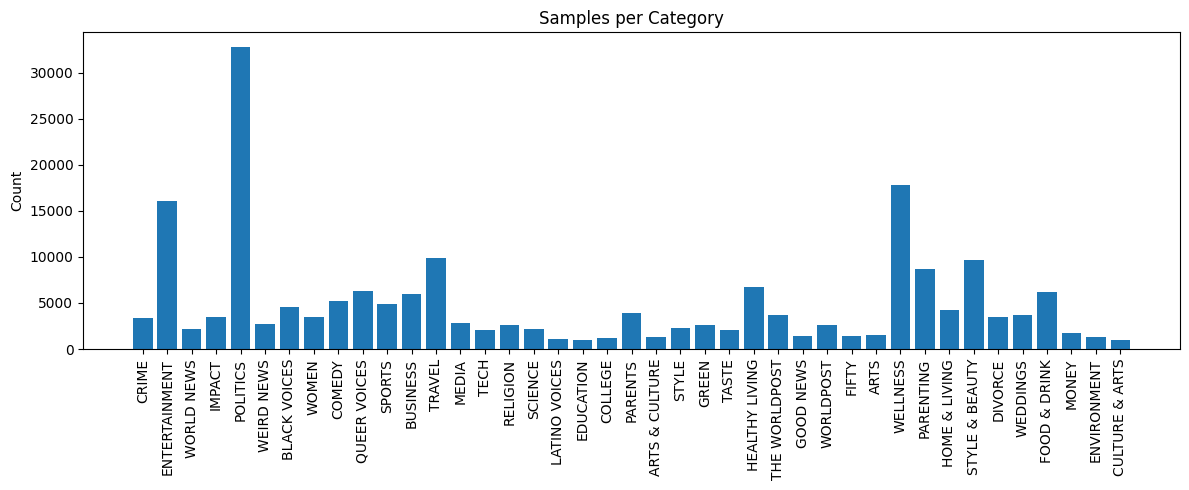

In [14]:
label_counts = Counter(huff_all['category'])
labels, counts = zip(*label_counts.items())
plt.figure(figsize=(12, 5))
plt.bar(labels, counts)
plt.xticks(rotation=90)
plt.title("Samples per Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Missing or inconsistent data

In [15]:
# Count missing or empty headlines in the dataset.
missing_headline = sum([not (ex or "").strip() for ex in huff_all['headline']])

# Count missing or empty short descriptions in the dataset.
missing_desc = sum([not (ex or "").strip() for ex in huff_all['short_description']])

# Print the number of missing headlines.
print(f"Missing headlines: {missing_headline}")

# Print the number of missing short descriptions.
print(f"Missing short descriptions: {missing_desc}")

Missing headlines: 6
Missing short descriptions: 19712


### Duplicates / near-duplicates

In [16]:
# Combine the 'headline' and 'short_description' fields for each news article into a single string,
# using " [SEP] " as a separator. If either field is missing or empty, it is replaced with an empty string.
combined_texts = [(ex['headline'] or "") + " [SEP] " + (ex['short_description'] or "") for ex in huff_all]

# Count the number of unique combined text samples by converting the list to a set (which removes duplicates).
num_unique = len(set(combined_texts))

# Calculate the number of duplicate samples by subtracting the number of unique samples from the total number of samples.
num_duplicates = num_samples - num_unique

# Print the number of duplicate samples found in the dataset.
print(f"Duplicate samples (exact text): {num_duplicates}")

Duplicate samples (exact text): 488


### Text statistics

In [17]:
# For each news article in the dataset, combine the 'headline' and 'short_description' fields into a single string,
# separated by a space. If either field is missing or empty, it is replaced with an empty string.
word_counts = [len(((ex['headline'] or "") + " " + (ex['short_description'] or "")).split()) for ex in huff_all]

# Calculate the average number of words per sample by dividing the total word count by the number of samples.
avg_words = sum(word_counts) / len(word_counts)

# Print the average words per sample, formatted to two decimal places.
print(f"Average words per sample: {avg_words:.2f}")

Average words per sample: 29.27


### Word frequency plot for a category

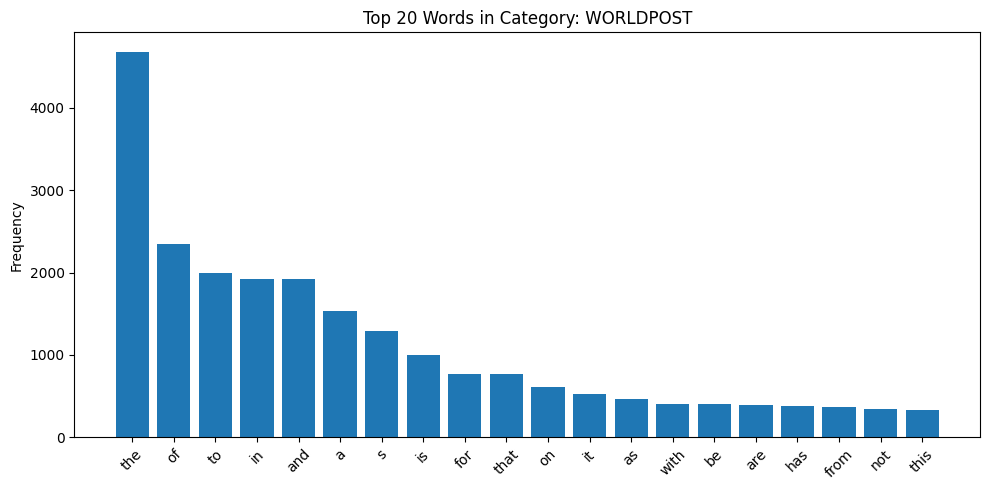

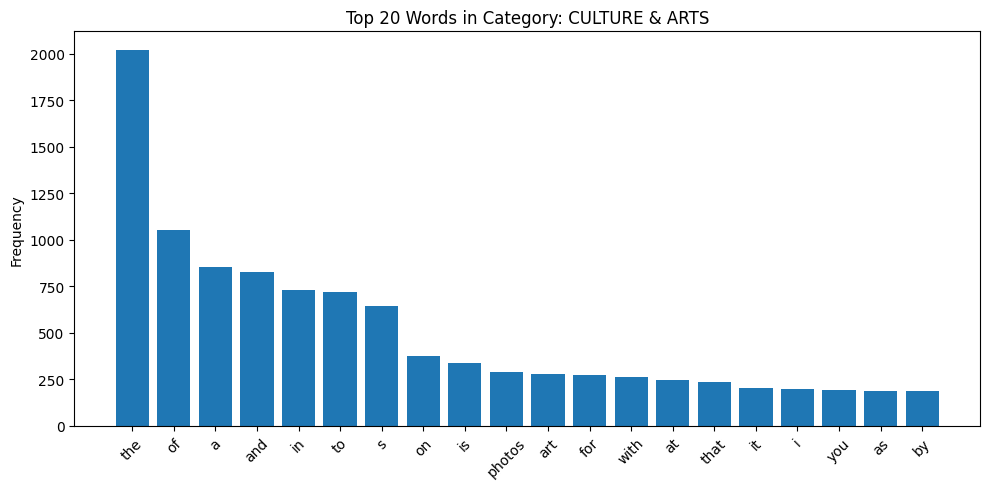

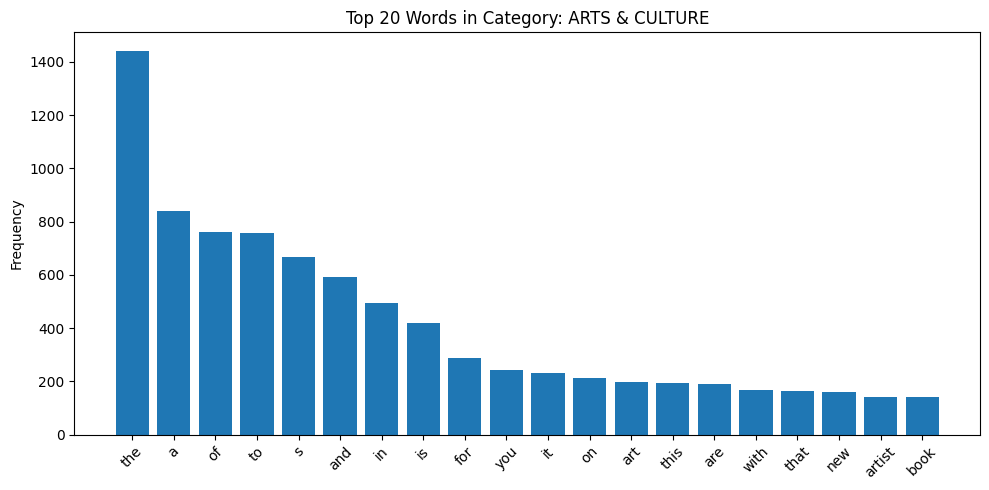

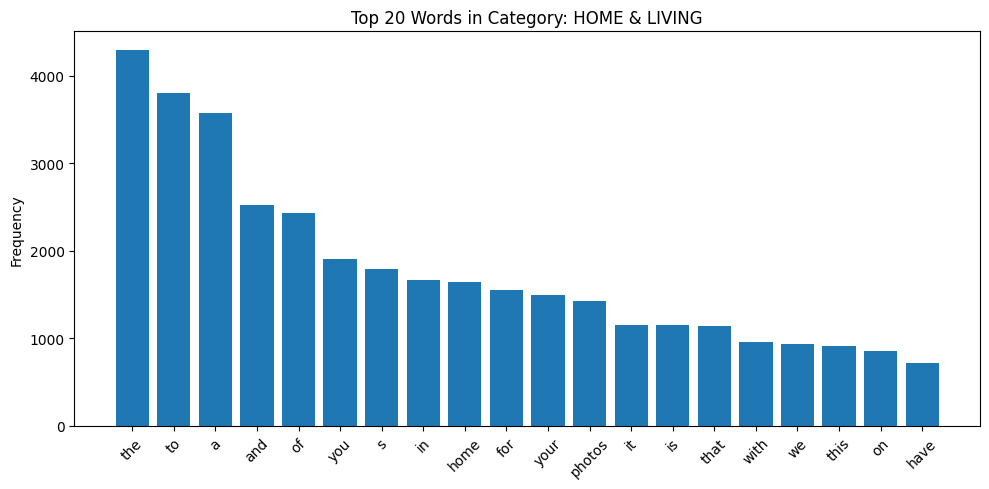

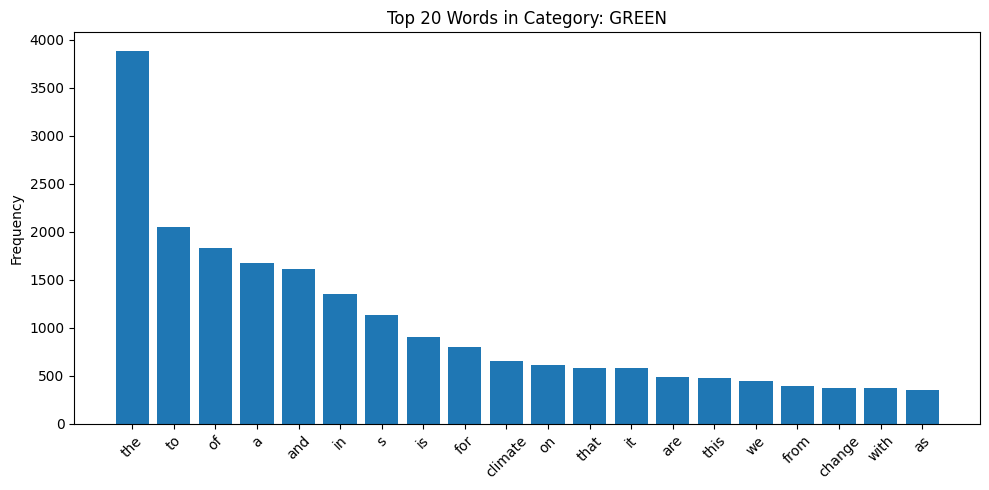

In [18]:
# Define a helper function to extract all word tokens from a text string, converting to lowercase.
def get_words(text):
    return re.findall(r'\b\w+\b', text.lower())

# Randomly select 5 categories from the list of all categories.
selected_categories = random.sample(categories, 5)

# For each selected category, generate a bar plot of the 20 most frequent words.
for category in selected_categories:
    # Gather all combined headline and short description texts for the current category.
    texts = [
        (ex['headline'] or "") + " " + (ex['short_description'] or "")
        for ex in huff_all if ex['category'] == category
    ]
    all_words = []
    # Tokenize each text and accumulate all words.
    for text in texts:
        all_words.extend(get_words(text))

    # Count word frequencies and select the 20 most common words.
    word_freq = Counter(all_words)
    common_words = word_freq.most_common(20)
    words, freqs = zip(*common_words)

    # Plot a bar chart of the top 20 words for the current category.
    plt.figure(figsize=(10, 5))
    plt.bar(words, freqs)
    plt.xticks(rotation=45)
    plt.title(f"Top 20 Words in Category: {category}")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

### Graded Questions (2 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible.

1. **Dataset Summary:**  
   Describe your chosen dataset  (as if explaining to your *clueless boss* what you are working on).
   - State which dataset you are going to use.   
   - What kind of data does it contain (images or text)?  
   - How many samples and classes are there?  
   - What is the task you’ll perform (classification into what categories)?
   - What is the potential business use for this dataset?

1.1. **Your answer here:**



For our project, we are using the HuffPost News Category dataset. This dataset contains text data—specifically, short news articles, each with a headline and a brief description. There are about 200,000 samples in total, and each article is labeled with one of 41 possible topical categories, such as POLITICS, ENTERTAINMENT, or PARENTING.

Our main task is to build a model that can automatically classify a given news headline and summary into one of these 41 categories. This means, for any new article, the model will predict which topic it belongs to.

The potential business use for this dataset is significant: an automated news categorization system can help media companies organize content more efficiently, improve user experience through better recommendations, and enable targeted advertising by understanding the topics of articles in real time.

2. **Initial Observations:**  
   What stood out to you from your EDA?  
   - Did you notice any imbalanced or ambiguous classes?  
   - Any patterns, anomalies, or potential sources of bias?  
   - For images: note any variation in lighting, composition, or color.  
   - For text: mention redundancy, topic overlap, or very short examples.

1.2. **Your answer here:**

During our EDA, we noticed a few ambiguous classes. This included titles such as "Fifty", "Green", and "Impact". These classes are very broad and are not clear on what the articles might focus on. For example, does green relate to sustainability or the color? Does fifty relate to an age, a year, or a quantity? In addition, some of the classes appeared to overlap. There is "Arts", "Arts & Culture", and "Culture & Arts" then "The Worldpost" and "Worldpost". It is unclear what characteristics differentiate between each of these categories and if there is a difference between them.

Out of the 200,000 samples, "Politics" made up over 32,739 of them. The next two highest classes were "Wellness" (17,827 samples) and "Entertainment" (16,058 samples). After those three, all the classes had less than 10,000 samples displaying a clear imbalance amongst the classes and potential for a model to be biased towards those categories. In addition, we found there to be 6 missing headlines, 19,712 missing short descriptions, and 488 duplicate samples. This indicates a need for data cleaning and preprocessing to remove duplicates and handle missing values.

3. **Challenges & Implications:**  
   Based on your inspection, what challenges might affect model performance or training (e.g., imbalance, ambiguous labels, variable quality)?  

1.3. **Your answer here:**

As mentioned above, one of the biggest challenges that may affect model performance and training is the class imbalance between "Politics", "Wellness", and "Entertainment" and the other categories. The three mentioned classes make up about 33% of the total samples so the model will want to favor those classes and may perform poorly on those that are underrepresented. In addition, overlapping labels, such as "Arts", "Arts & Culture", and "Culture & Arts", "The Worldpost" and "Worldpost", then "Wellness" and "Healthy Living" may confuse the model and lead to inaccurate classification since it is unclear what the difference between the overlapping categories are. Lastly, duplicate samples, missing headlines, and missing short descriptions will need to be addressed in order to prevent the model from overfitting or training on inaccurate data.   

4. **Preparation Ideas:**  
   What data-cleaning or preprocessing steps might help address these issues?  
   (You will not implement these yet—just describe what you might do later.)

1.4. **Your answer here:**

To address the issues identified, we will first remove all duplicate samples to prevent the model from overfitting. Next, we will remove the 6 samples with missing headlines. To address the 19,712 samples missing short descriptions, we will either fill the short descriptions in using the headline or use an empty string, then concatenate the headline and description with [SEP]. We will not remove the samples missing short descriptions as that is a large amount of trainable data that can be used in our model. Next, to address the overlapping labels, we will merge the categories into one overarching class. For example, “Arts,” “Arts & Culture,” and “Culture & Arts” can become one category which help our model be more accurate and less confused. In addition, to minimize the class imbalance, we can standarize the features or apply class weighting during training. We also will ensure all the inputs are consistent, we will normalize text fields by removing special characters, lowercasing, and applying other text cleaning processes. Finally, exploratory checks to find short samples will be performed to help determine what content is necessary or irrelevant for model training.


5. **Reflection:**  
   Why did you choose this dataset over the other one?  
   - What makes it more interesting, realistic, or relevant for you?  
   - What do you expect to learn from working with it?

1.5. **Your answer here:**

We chose the HuffPost dataset due to diverse and realistic nature of the dataset. This dataset offers about 200,000 samples of headline/summary pairs across 41 topics. It reflects an accurate representation of what articles in the 'real world' look like; they vary in topic, writing style, and length. This classification task will allow us to challenge ourselves by exploring and addressing class imbalance, category overlap, and variable length inputs. The Food-101 dataset which focuses on image-specific preprocessing offers an interesting task that involves dealing with inconsistent lighting, white balance, color casts, composition, and different resolutions. Although, it does not focus on text based preprocessing, data cleaning, and standard performance metrics (e.g. accuracy, f1). We find these categories to be more in line with the real world  Natural Language Processing applications that we will see in our respective fields and wanted to explore and strengthen our skills in this area, especially with our graduation date approaching.




## Problem 2 – Frame the Problem (15 pts)

#### Objective

Identify the **key challenges** in your chosen dataset and outline **practical solutions** you would try, plus how you’ll **evaluate** them later.

#### Steps to follow

1. **Diagnose likely challenges (from your EDA):**

   Examples:
   * **Class imbalance:**
     Report label counts and an imbalance ratio (max / median). List any minority classes.
   * **Length/size variance:**
     For text, show length percentiles (50/75/90/95) and estimate truncation rate at candidate `max_text_length`s (e.g., 256/300/512). For images, summarize native resolutions.
   * **Noise/duplicates/leakage:**
     Note empty or malformed items, near-duplicates, and how you would prevent cross-split leakage.
   * **Ambiguous/overlapping labels:**
     Give 2–3 example pairs you expect to be confusable and why.
   * **Compute constraints:**
     Briefly state limits (RAM/GPU/CPU) that might affect batch size, sequence length, or image size.

2. **Map each challenge to a concrete solution plan:**

   Examples:
   * **Imbalance →** `class_weight` or oversampling; report which one you’d try first and why.
   * **Length/size →** pick a target `max_text_length` (e.g., 95th percentile) with masking; for images, standardize resize/crop and basic augmentation.
   * **Noise/duplicates →** dedupe (hash/near-dup), drop empty/very short items, document any relabeling.
   * **Ambiguity →** consider merging labels (if justified), or add features (bigrams/char-ngrams; simple image augmentations).
   * **Overfitting risk →** early stopping on your primary metric, dropout/weight decay, freeze-then-finetune plan (for pretrained features).

3. **Explore appropriate evaluation metrics:**

   Examples:
   * **Primary metric:** pick one aligned to your data (e.g., **macro-F1** if imbalanced; accuracy if balanced).
   * **Secondary metric(s):** per-class precision/recall, confusion matrix.
   * **Protocol:** stratified Train/Val/Test (e.g., 70/15/15), fixed seed, leakage checks.

4. **Answer the graded questions below.**



In [19]:
# Your code here, add as many cells as you like. Provide organization and structure by appropriate comments, labels, and variable names. Explain what
# you are doing in case you come back to this in a year.



###Class Imbalance Analysis

In [20]:
# Quantifying the class imbalance to understand potential bias

# Computing imbalance stats
label_counts = Counter(huff_all['category'])
counts_sorted = sorted(label_counts.values(), reverse=True)
max_count = counts_sorted[0]
median_count = np.median(counts_sorted)
min_count = counts_sorted[-1]
imbalance_ratio = max_count/median_count

print("Class Imbalance Statistics:")
print(f"- Max samples in a class: {max_count}")
print(f"- Median samples per class: {median_count}")
print(f"- Min samples in a class: {min_count}")
print(f"- Imbalance ratio (max / median): {imbalance_ratio:.2f}\n")

# Identifying minority classes (less than 5% of max class)
threshold = 0.05 * max_count
minority_classes = [label for label, count in label_counts.items() if count < threshold]
print(f"Minority classes (< 5% of largest class, < {threshold:.0f} samples):")
for label in sorted(minority_classes):
    print(f"- {label}: {label_counts[label]} samples")

Class Imbalance Statistics:
- Max samples in a class: 32739
- Median samples per class: 3405.0
- Min samples in a class: 1004
- Imbalance ratio (max / median): 9.61

Minority classes (< 5% of largest class, < 1637 samples):
- ARTS: 1509 samples
- ARTS & CULTURE: 1339 samples
- COLLEGE: 1144 samples
- CULTURE & ARTS: 1030 samples
- EDUCATION: 1004 samples
- ENVIRONMENT: 1323 samples
- FIFTY: 1401 samples
- GOOD NEWS: 1398 samples
- LATINO VOICES: 1129 samples


###Text Length/Size Varience

In [21]:
# Text length distribution
# Computing the word counts for combined headline + short_description
word_counts = []
for ex in huff_all:
    headline = ex['headline'] or ""
    desc = ex['short_description'] or ""
    combined = headline + " " + desc
    word_counts.append(len(combined.split()))

word_counts = np.array(word_counts)

# Calculate length percentiles
percentiles = [50, 75, 90, 95, 99]
length_stats = {p: np.percentile(word_counts, p) for p in percentiles}
print("Text Length Stats (words):")
print(f"- Mean: {np.mean(word_counts):.1f}")
print(f"- Median (50th percentile): {length_stats[50]:.0f}")
print(f"- 75th percentile: {length_stats[75]:.0f}")
print(f"- 90th percentile: {length_stats[90]:.0f}")
print(f"- 95th percentile: {length_stats[95]:.0f}")
print(f"- 99th percentile: {length_stats[99]:.0f}")

# Estimate truncation rates for different max_length values
candidate_lengths = [256, 300, 512]

print("\nTruncation Analysis:")
for max_len in candidate_lengths:
    # Rough estimate: 1 word = 1.3 tokens (typical for English)
    max_words = int(max_len / 1.3)
    truncated = np.sum(word_counts > max_words)
    truncation_rate = (truncated / len(word_counts)) * 100
    print(f"  Max length {max_len} tokens (~{max_words} words): {truncation_rate:.2f}% samples truncated")

Text Length Stats (words):
- Mean: 29.3
- Median (50th percentile): 28
- 75th percentile: 35
- 90th percentile: 49
- 95th percentile: 56
- 99th percentile: 67

Truncation Analysis:
  Max length 256 tokens (~196 words): 0.00% samples truncated
  Max length 300 tokens (~230 words): 0.00% samples truncated
  Max length 512 tokens (~393 words): 0.00% samples truncated


###Noise, Duplicates, Leakage

In [22]:
print("Analysis of dataset:")
print(f"- Total samples: {num_samples}")
print(f"- Missing headlines: {missing_headline}")
print(f"- Missing short descriptions: {missing_desc}")
print(f"- Duplicate samples (exact text): {num_duplicates}")
print(f"- Samples with missing headline or description: {missing_headline + missing_desc}\n")

# Calculate percentage of affected samples
missing_headline_pct = (missing_headline / num_samples) * 100
missing_desc_pct = (missing_desc / num_samples) * 100
duplicate_pct = (num_duplicates / num_samples) * 100

print("% of Affected Samples:")
print(f"- Missing headlines: {missing_headline_pct:.2f}%")
print(f"- Missing descriptions: {missing_desc_pct:.2f}%")
print(f"- Duplicates: {duplicate_pct:.2f}%")

Analysis of dataset:
- Total samples: 200853
- Missing headlines: 6
- Missing short descriptions: 19712
- Duplicate samples (exact text): 488
- Samples with missing headline or description: 19718

% of Affected Samples:
- Missing headlines: 0.00%
- Missing descriptions: 9.81%
- Duplicates: 0.24%


###Ambiguous/Overlapping Labels

In [23]:
# Defining groups of potentially overlapping categories
overlapping_groups = [
    ['ARTS', 'ARTS & CULTURE', 'CULTURE & ARTS'],
    ['WORLDPOST', 'THE WORLDPOST'],
    ['WELLNESS', 'HEALTHY LIVING'],
    ['PARENTS', 'PARENTING'],
    ['STYLE', 'STYLE & BEAUTY']
]

print("Potentially Overlapping Groups")
for i, group in enumerate(overlapping_groups, 1):
    print(f"\n{i}.{' vs '.join(group)}")
    for label in group:
        if label in label_counts:
            print(f"- {label}: {label_counts[label]} samples")

print("\nAmbiguous Single Categories (unclear topic scope):")
ambiguous = ['FIFTY', 'GREEN', 'IMPACT', 'TASTE', 'GOOD NEWS']
for label in ambiguous:
    if label in label_counts:
        print(f"- {label}: {label_counts[label]} samples")

Potentially Overlapping Groups

1.ARTS vs ARTS & CULTURE vs CULTURE & ARTS
- ARTS: 1509 samples
- ARTS & CULTURE: 1339 samples
- CULTURE & ARTS: 1030 samples

2.WORLDPOST vs THE WORLDPOST
- WORLDPOST: 2579 samples
- THE WORLDPOST: 3664 samples

3.WELLNESS vs HEALTHY LIVING
- WELLNESS: 17827 samples
- HEALTHY LIVING: 6694 samples

4.PARENTS vs PARENTING
- PARENTS: 3955 samples
- PARENTING: 8677 samples

5.STYLE vs STYLE & BEAUTY
- STYLE: 2254 samples
- STYLE & BEAUTY: 9649 samples

Ambiguous Single Categories (unclear topic scope):
- FIFTY: 1401 samples
- GREEN: 2622 samples
- IMPACT: 3459 samples
- TASTE: 2096 samples
- GOOD NEWS: 1398 samples


###Length Distribution

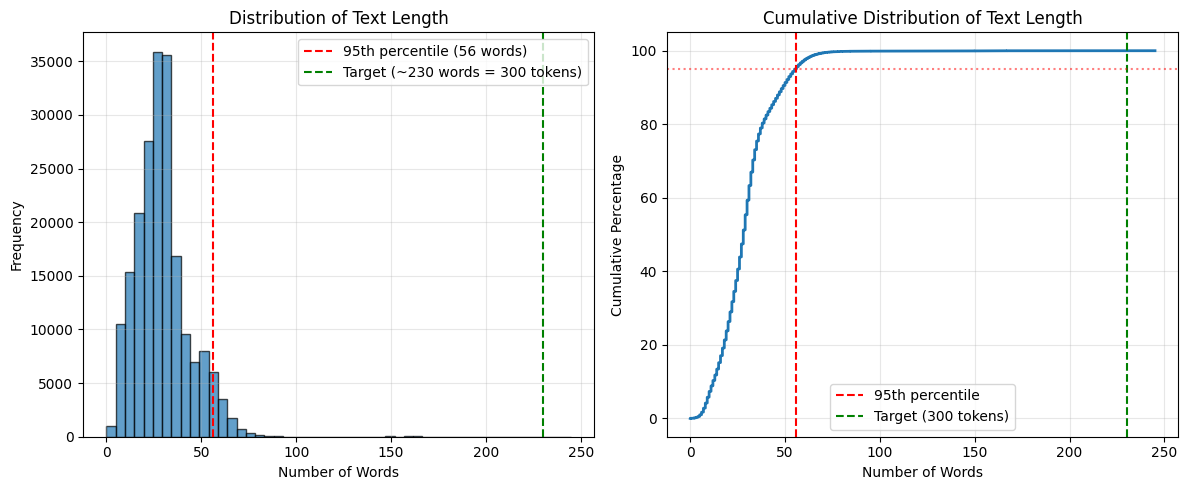


At 300 tokens (~230 words), we capture 100.0% of samples completely


In [24]:
plt.figure(figsize=(12, 5))
# Histogram of word counts
plt.subplot(1, 2, 1)
plt.hist(word_counts, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(length_stats[95], color='red', linestyle='--', label=f'95th percentile ({length_stats[95]:.0f} words)')
plt.axvline(230, color='green', linestyle='--', label='Target (~230 words = 300 tokens)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Distribution of Text Length')
plt.legend()
plt.grid(True, alpha=0.3)

# Cumulative distribution
plt.subplot(1, 2, 2)
sorted_counts = np.sort(word_counts)
cumulative = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts) * 100
plt.plot(sorted_counts, cumulative, linewidth=2)
plt.axvline(length_stats[95], color='red', linestyle='--', label=f'95th percentile')
plt.axvline(230, color='green', linestyle='--', label='Target (300 tokens)')
plt.axhline(95, color='red', linestyle=':', alpha=0.5)
plt.xlabel('Number of Words')
plt.ylabel('Cumulative Percentage')
plt.title('Cumulative Distribution of Text Length')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAt 300 tokens (~230 words), we capture {np.sum(word_counts <= 230) / len(word_counts) * 100:.1f}% of samples completely")

###Label Merging Analysis

In [25]:
# Using mapping for label merging
label_merge_map = {
    'ARTS': 'ARTS',
    'ARTS & CULTURE': 'ARTS',
    'CULTURE & ARTS': 'ARTS',
    'WORLDPOST': 'WORLDPOST',
    'THE WORLDPOST': 'WORLDPOST',
    'WELLNESS': 'WELLNESS',
    'HEALTHY LIVING': 'WELLNESS',
    'PARENTS': 'PARENTING',
    'STYLE': 'STYLE',
    'STYLE & BEAUTY': 'STYLE'
}

# Apply merging to create new label distribution
merged_labels = []
for ex in huff_all:
    original_label = ex['category']
    merged_label = label_merge_map.get(original_label, original_label)
    merged_labels.append(merged_label)

merged_counts = Counter(merged_labels)
num_merged_classes = len(merged_counts)

print("Label Merging Stats:\n")
print(f"Original number of classes: {num_classes}")
print(f"After merging: {num_merged_classes}")
print(f"Classes reduced by: {num_classes - num_merged_classes}")
print()

print("Merged Category Stats:")
for original, merged in sorted(label_merge_map.items()):
    if original != merged:
        print(f"  {original} ({label_counts[original]}) -> {merged}")

print()
print("New Merged Category Counts:")
merged_categories = [label for label in merged_counts.keys() if label in label_merge_map.values()]
for label in sorted(merged_categories):
    print(f"  {label}: {merged_counts[label]} samples")

Label Merging Stats:

Original number of classes: 41
After merging: 35
Classes reduced by: 6

Merged Category Stats:
  ARTS & CULTURE (1339) -> ARTS
  CULTURE & ARTS (1030) -> ARTS
  HEALTHY LIVING (6694) -> WELLNESS
  PARENTS (3955) -> PARENTING
  STYLE & BEAUTY (9649) -> STYLE
  THE WORLDPOST (3664) -> WORLDPOST

New Merged Category Counts:
  ARTS: 3878 samples
  PARENTING: 12632 samples
  STYLE: 11903 samples
  WELLNESS: 24521 samples
  WORLDPOST: 6243 samples


### Mapping Challenges to Solution Plan Quick Notes

1. Class Imbalance
    
    Solution:
    - Use class_weight='balanced' in model training as it automatically weights loss by inverse frequency, no data modification needed, and it works well with the 9.6:1 imbalance ratio (max/median). If the initial approach doesn't sufficiently address minority class performance, we can use stratified sampling or apply SMOTE oversampling for classes with fewer than 1,600 samples.
    
    Evaluation:
    - Track both accuracy and macro-F1 score to ensure performance across all classes, not just dominant ones (POLITICS, WELLNESS, ENTERTAINMENT). Monitor per-class F1 scores for the 9 minority classes identified.

2. Text Length Variance
    
    Solution:
    - Target max_length of 128 tokens (approximately 100 words) which comfortably captures 100% of samples based on our analysis showing 99th percentile at only 67 words. Use padding and attention masking for shorter sequences.
    - All samples fit within 128 tokens with substantial headroom, allowing us to use smaller sequence lengths than initially planned. This reduces computational cost and memory usage while maintaining full coverage. The original target of 300 tokens was overly conservative.


3. Missing Data
    
    Solution:
    - Remove 6 samples with missing headlines (0.00% of data) as headlines are critical for classification.
    - For 19,712 samples with missing descriptions (9.81%): use headline only and concatenate with empty string (e.g., 'headline [SEP] ').
    - 19,712 samples represent nearly 10% of the dataset and are too valuable to discard. Headlines alone provide sufficient signal for classification, and many news headlines are designed to be self-contained summaries.

4. Duplicates
   
    Solution:
    - Remove 488 exact duplicates (0.24% of data) using hash-based deduplication before creating train/val/test splits to prevent data leakage across splits.
    - While duplicates represent a small fraction of data, they could cause overfitting which would artificially inflate validation performance if they appear in both training and validation sets. This would allow for clean evaluation.


5. Overlapping and Ambiguity
    
    Solution:
    - Merge similar categories to reduce confusion and increase sample sizes. For example:
        - 'ARTS' + 'ARTS & CULTURE' + 'CULTURE & ARTS' -> 'ARTS' (3,878 samples)
        - 'WORLDPOST' + 'THE WORLDPOST' -> 'WORLDPOST' (6,243 samples)
        - 'WELLNESS' + 'HEALTHY LIVING' -> 'WELLNESS' (24,521 samples)
        - 'PARENTS' + 'PARENTING' -> 'PARENTING' (12,632 samples)
        - 'STYLE' + 'STYLE & BEAUTY' -> 'STYLE' (11,903 samples)
    - This reduces classes from 41 to 35, eliminating 6 redundant categories.
    - We can also consider further merging or removing highly ambiguous categories ('FIFTY', 'GREEN', 'IMPACT', 'TASTE', 'GOOD NEWS') if they show poor performance during validation, as their topical scope is unclear.

6. Overfitting Prevention
   
    Solution:
    - Implement early stopping with patience=3 epochs monitoring validation macro-F1 score.
    - Add dropout layers (rate=0.3-0.5) in classifier head.
    - Apply L2 regularization (weight_decay=0.01) to model weights.
    - If using pretrained embeddings: freeze initially, then fine-tune in later epochs with lower learning rate (e.g., 2e-5 for fine-tuning vs 1e-4 for classifier head).
    - The idea is that using multiple regulatization strategies can work together to prevent model memorization and hopefully improve our generalization. By early stopping we can prevent training beyond an optimal point. Dropout will force the model to learn robust features. Weight decay will prevent large parameter values that indicate overfitting.

###Compute Constraints

    Environment:
    - Platform: Google Colab Pro (Student Version)
    - GPU: NVIDIA A100 (40GB VRAM)
    - System RAM: 83.5 GB available
    - Disk: 235.7 GB available
    - Session: No timeout constraints (Pro subscription)
    - Batch size: 64-128 for transformer models, 256-512 for simpler models
      (A100 memory allows for larger batches than standard Colab)
    - Sequence length: Can comfortably use 512 tokens, but 300 is optimal for this dataset based on text length analysis
    - Model size: Can train BERT-large (340M params), RoBERTa-large, or even T5-base without memory issues
    - Training time: Budget 1-2 hours for full training with early stopping (A100 is significantly faster than T4) (Also I believe colab stops runtime after a period of time)

### Graded Questions (3 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible.

1. **State the prediction task**  
   - Describe what your model will predict (the *label*).  
   - *Examples:*  
     - “Given a photo of food, predict which of 101 categories it belongs to.”  
     - “Given a news headline + summary, predict its topical category.”  

2.1. **Your answer here:**
Given a news headline and short description, the model will predict the topical category of the article. This means, for any news article, the model will automatically determine which topic it belongs to (e.g. Politics, Arts, Wellness, etc.). This has the potential for a significant impact in the media, marketing, and business fields which can utilize this model for personalized recommendations and automatic content organization in real time.

2. **Define inputs and outputs**  
   - *Inputs:* what information the model receives (e.g., pixel data, tokenized text).  
   - *Outputs:* the categorical label the model will predict.  

2.2. **Your answer here:**
For each sample the model will input a single text string by concatenating the headline and short description using a BERT-compatible separator token ([SEP]). The output of the model will then be a single categorical label to indicate the category of the article.


3. **Identify possible challenges**  
   - Imbalanced classes, noisy data, ambiguous labels, overlapping features, or missing data  
   - *Images:* variation in lighting, color, composition, or size.  
   - *Text:* class imbalance, duplicate stories, short or ambiguous headlines.  

2.3. **Your answer here:**

With the HuffPost News Category dataset there are a few challenges we will need to address to ensure our model performs accurately and efficiently. Class imbalance is a major issue in this dataset as three of the categories ("Politics", "Wellness", and "Entertainment") make up about 33% of the total samples so the model will want to favor those classes and may perform poorly on those that are underrepresented. In addition, there are overlapping labels in the dataset that will need to be defined in order to ensure the model performs accurately. For example, there are three categories titled "Arts", "Arts & Culture", and "Culture & Arts" and two categories titled "Parents" and "Parenting". This dataset also has some ambiguous labels such as "Impact" and "Green". Defining the categories with distinct and clear descriptions will help the model learn and train more accurately and be more successful when implementation occurs. Lastly, duplicate samples (488 samples), missing headlines (6 samples), and missing short descriptions (19,712 samples) will need to be addressed in order to prevent the model from overfitting or training on inaccurate data. This will entail removing duplicates, using class weights, and concatenating with empty strings.

4. **Propose how you will prepare or improve the data to address the challenges**  
   - *Images:* resizing, normalization, data augmentation (flips, rotations, brightness, color jitter).  
   - *Text:* tokenization, stop-word removal, TF-IDF, class balancing, embeddings (choose an embedding approach and specify its vector size).

2.4. **Your answer here:**
To prepare and improve the HuffPost News Category dataset for modeling, we will take the following steps:

* Tokenization: We will use a pretrained transformer tokenizer (such as DistilBERT or BERT) to split the combined headline and short description into tokens. This ensures compatibility with modern NLP models and handles subword units for rare or unknown words.
* Stop-word removal: For classical ML baselines (e.g., TF-IDF + logistic regression), we will remove common English stop words using spaCy or NLTK to reduce noise and focus on informative terms. For transformer models, we will use raw text, as these models are trained to handle stop words.
* TF-IDF: For non-neural baselines, we will compute TF-IDF vectors from the cleaned text. This will help capture the importance of words relative to each category. We will set the vector size to 10,000 features to balance expressiveness and computational efficiency.
* Class balancing: To address class imbalance, we will use class weighting during model training (e.g., class_weight='balanced' in scikit-learn or Keras). If needed, we may also experiment with oversampling minority classes.
* Embeddings: For deep learning models, we will use pretrained transformer embeddings (e.g., DistilBERT, vector size 768). For classical models, we may use averaged GloVe embeddings (vector size 300) as an alternative.
* Additional cleaning: We will remove duplicates, drop samples with missing headlines, and merge overlapping/ambiguous categories as identified in our EDA. We will also lowercase all text and remove special characters for consistency.


5. **Specify success metrics**  
   - Identify the metrics you plan to use to evaluate model performance—typically **accuracy** and/or **F1-score**, which are standard for classification tasks.  
   - Briefly explain **why** these metrics are appropriate for your dataset and goal. For instance, accuracy may suffice for well-balanced datasets, while F1-score better reflects performance when some classes are under-represented.
   - If your dataset is **imbalanced**, consider computing **per-class metrics** (e.g., precision, recall, or F1 for each label) or **macro-averaged** scores, which give equal weight to each class regardless of its size—ensuring that minority classes are evaluated fairly.
In some cases, weighted averages (which weight classes by their frequency) or **confusion matrices** can also provide useful insight.
> You haven't run any models yet, and we haven’t studied every possible metric, but you’re encouraged to ask your favorite generative AI tool which evaluation metrics might best fit your dataset!
   - Clearly state how you will interpret success—for example, “Our goal is to achieve at least 80% overall accuracy without large per-class disparities.”

2.5. **Your answer here:**



For this project, we will use both accuracy and F1-score as our primary evaluation metrics. Accuracy measures the overall proportion of correct predictions, which is useful for a general sense of model performance. However, because our dataset is imbalanced (some categories have far more samples than others), accuracy alone could be misleading, high accuracy can be achieved by favoring the majority classes.

The F1 score gives equal weight to each class, regardless of its size, and is therefore more appropriate for imbalanced datasets. It ensures that performance on minority classes is not ignored. In addition, we will examine per-class precision, recall, and F1 scores, as well as the confusion matrix, to identify which categories are most challenging for the model.

Success will be defined as achieving at least 80% overall accuracy and a F1 score above 0.70, with no major disparities between classes (i.e., minority classes should not have near-zero F1 scores). This approach ensures fair evaluation across all categories and helps us identify and address any weaknesses in the model.

### Final Question: Describe what use you made of generative AI tools in preparing this Milestone.

**AI Question: Your answer here:**

1) Used ChatGPT to help explain the difference between Hugging Face Datasets and traditional data structures like NumPy arrays or Pandas DataFrames. This helped clarify how to access and manipulate the data effectively within the notebook.

2) Used ChatGPT to brainstorm potential data cleaning and preprocessing steps for the HuffPost text dataset, which helped refine our approach to handling missing data and class imbalance.

---

## Appendix: A quick guide to Hugging Face Datasets

#### 1) What are they?

* A **table-like** dataset: rows = examples, columns = named fields (e.g., `"image"`, `"label"`, `"headline"`).
* Backed by **Apache Arrow** → fast, memory-efficient, lazy transforms.
* Two core objects:

  * `Dataset` — one table of rows/columns.
  * `DatasetDict` — a dict of splits, e.g. `{"train": Dataset, "val": Dataset, "test": Dataset}`.


#### 2) Load and inspect

```python
from datasets import load_dataset

# Food-101 (images)
food = load_dataset("food101", split="train+validation")  # both splits at once
len(food), food.column_names, food.features
# -> (≈101000, ['image','label'], {'label': ClassLabel(num_classes=101, names=[...])})

# Access by name (not by numeric column index!)
row0 = food[0]
img0, y0 = row0["image"], row0["label"]     # PIL image, int id
label_names = food.features["label"].names
label_names[y0]
```

For text (HuffPost JSON mirror):

```python
url = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff = load_dataset("json", data_files=url, split="train")
huff.column_names  # e.g. ['headline','short_description','category','authors','link','date']
```


#### 3) Common transforms

`Dataset`s are **immutable**: ops return a new dataset.

* **Map** (add/modify columns):

```python
def mk_text(ex):
    h = (ex.get("headline") or "").strip()
    s = (ex.get("short_description") or "").strip()
    return {"text": (h + " [SEP] " + s).strip()}

huff = huff.map(mk_text)  # adds 'text' column
```

* **Class-encode** labels (strings → integers with a vocabulary):

```python
from datasets.features import ClassLabel
if not isinstance(huff.features["category"], ClassLabel):
    huff = huff.class_encode_column("category")  # now ints with .names
```

* **Filter / select / rename / drop**:

```python
small = huff.select(range(5000))  # first 5k rows
huff = huff.remove_columns(["authors","link","date"])
huff = huff.rename_column("category", "label")
```


#### 4) Splitting & shuffling

```python
# Stratified 80/10/10 on Food-101 by 'label'
from datasets import DatasetDict
label_col = "label"

tmp = food.train_test_split(test_size=0.10, seed=42, stratify_by_column=label_col)
train_val = tmp["train"].train_test_split(test_size=1/9, seed=42, stratify_by_column=label_col)
ds = DatasetDict(train=train_val["train"], val=train_val["test"], test=tmp["test"])

len(ds["train"]), len(ds["val"]), len(ds["test"])
```

* `train_test_split` is **random by default** (reproducible with `seed=`).
* You typically **don’t need to pre-shuffle** datasets if your training dataloader already shuffles each epoch.


#### 5) Working with images

Use `with_transform` to apply on-the-fly resizing/augmentation and return tensors:

```python
import torchvision.transforms as T
from torch.utils.data import DataLoader
import torch, math, random

IM_SIZE = 224
train_tfms = T.Compose([T.RandomResizedCrop(IM_SIZE), T.RandomHorizontalFlip(), T.ToTensor()])
eval_tfms  = T.Compose([T.Resize(256), T.CenterCrop(IM_SIZE), T.ToTensor()])

def add_pixel_values(ex, tfms):  # ex['image'] -> ex['pixel_values']
    ex = dict(ex); ex["pixel_values"] = tfms(ex["image"]); return ex

train_t = ds["train"].with_transform(lambda ex: add_pixel_values(ex, train_tfms))
val_t   = ds["val"].with_transform(lambda ex: add_pixel_values(ex, eval_tfms))

def collate(batch):
    return {"pixel_values": torch.stack([b["pixel_values"] for b in batch]),
            "labels": torch.tensor([b["label"] for b in batch])}

train_loader = DataLoader(train_t, batch_size=64, shuffle=True,  collate_fn=collate)
val_loader   = DataLoader(val_t,   batch_size=64, shuffle=False, collate_fn=collate)
```

### 6) Working with Text

You can preprocess and tokenize text datasets using either a **transformer tokenizer** or a **linguistic pipeline like spaCy**, depending on your model type and goals.


#### Option A: Transformer Tokenizer (for fine-tuning models like BERT or DistilBERT)

Use a pretrained tokenizer with the Hugging Face `map` method to efficiently process your dataset in batches:

```python
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tok(batch["text"], truncation=True, padding="max_length", max_length=128)

tokenized = huff.map(
    tokenize,
    batched=True,
    remove_columns=[c for c in huff.column_names if c not in ("category", "label")]
)
```

This produces token IDs, attention masks, and other fields expected by transformer models.
Use this approach if your project involves fine-tuning pretrained language models.


#### Option B: spaCy Tokenization and Cleaning (for classical ML or custom preprocessing)

If you are **not using transformers**, or if you want to explore feature engineering (e.g., TF-IDF, word frequency, or embedding averages), you can preprocess text with **spaCy** instead.

```python
# !pip install spacy
# !python -m spacy download en_core_web_sm

import spacy
from datasets import load_dataset

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser", "textcat"])
STOP = spacy.lang.en.stop_words.STOP_WORDS

def spacy_clean(batch):
    docs = list(nlp.pipe(batch["text"], batch_size=1000))
    cleaned = []
    for doc in docs:
        tokens = [t.lemma_.lower() for t in doc if t.is_alpha and not t.is_stop]
        cleaned.append(" ".join(tokens))
    return {"text_clean": cleaned, "len_tokens": [len(c.split()) for c in cleaned]}

huff = huff.map(
    spacy_clean,
    batched=True,
    batch_size=1000,
    remove_columns=[c for c in huff.column_names if c not in ("category", "label")]
)
```

The resulting column `text_clean` can be used with:

* `TfidfVectorizer` (Scikit-learn)
* `TextVectorization` (Keras)
* or any other custom embedding method.

> 💡 **Tip:** spaCy is ideal for lightweight NLP pipelines or for models that rely on explicit preprocessing (lemmatization, stopword removal). Transformer tokenizers, by contrast, expect *raw text* and handle subword tokenization internally.



#### 7) Slicing, concatenating, saving

```python
# Slicing
head_1000 = food.select(range(1000))
tail_10pct = food.select(range(int(0.9*len(food)), len(food)))

# Concatenate splits/datasets
from datasets import concatenate_datasets
all_train = concatenate_datasets([ds["train"], ds["val"]])

# Save / reload
ds.save_to_disk("food101_splits")
from datasets import load_from_disk
ds2 = load_from_disk("food101_splits")
```


#### 8) Quick “gotchas”

* **Columns by name** (strings), not numeric indices.
* Avoid converting huge columns to `list(...)` unless necessary; prefer vectorized ops with `map`, `filter`, `select`.
* `PYTHONHASHSEED` must be set **before** the Python process starts to matter; use explicit `seed=` arguments for reproducibility.
* Datasets print **previews** (e.g., `Column([6, 6, 6, ...])` is just the first few values).


#### 9) A minimal checklist to follow

1. `load_dataset(...)` → confirm `column_names`, `features`.
2. Build any needed columns (`"text"`), and **class-encode** labels if strings.
3. Make a **stratified 80/10/10** split (`train_test_split` ×2).
4. Do **EDA**: class counts, sample printouts or image grids.
5. For training:

   * **images** → `with_transform` + DataLoader
   * **text** → tokenizer via `.map(...)` + trainer/model pipeline
6. Save your `DatasetDict` with `save_to_disk(...)` (optional for text but handy, **don't** use it for big image datasets).

